# Flight Maneuver Classification - Exploratory Data Analysis

Understand the structure and distribution of flight maneuver accelerometer data.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [2]:
# Load training data
train_df = pd.read_csv('../data/train_set.csv')
test_df = pd.read_csv('../data/test_set.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"Test columns: {test_df.columns.tolist()}")

Train shape: (799994, 6)
Test shape: (200000, 6)

Train columns: ['maneuver_Id', 'timestamp', 'measurement_x', 'measurement_y', 'measurement_z', 'label']
Test columns: ['Unnamed: 0', 'maneuver_Id', 'timestamp', 'measurement_x', 'measurement_y', 'measurement_z']


In [3]:
# Inspect first rows
print("Training data sample:")
print(train_df.head())
print(f"\nLabel distribution:\n{train_df['label'].value_counts().sort_index()}")

Training data sample:
   maneuver_Id timestamp  measurement_x  measurement_y  measurement_z  label
0            0   50:34.3       0.798000      -0.023776       0.080064      1
1            0   50:34.4       0.795484      -0.031727       0.077065      1
2            0   50:34.4       0.793049      -0.039704       0.077875      1
3            0   50:34.5       0.790697      -0.047705       0.076800      1
4            0   50:34.5       0.788426      -0.055730       0.079076      1

Label distribution:
label
0    541030
1    165979
2     92985
Name: count, dtype: int64


## 3. Data Overview

In [4]:
# Data info
print("Missing values:")
print(train_df.isnull().sum())
print(f"\nUnique maneuvers: {train_df['maneuver_Id'].nunique()}")
print(f"\nMeasurements per maneuver:")
print(train_df.groupby('maneuver_Id').size().describe())

Missing values:
maneuver_Id        0
timestamp          0
measurement_x    798
measurement_y    156
measurement_z    145
label              0
dtype: int64

Unique maneuvers: 25706

Measurements per maneuver:
count    25706.000000
mean        31.120906
std         14.565659
min          1.000000
25%         21.000000
50%         30.000000
75%         40.000000
max        101.000000
dtype: float64


In [5]:
# Data types and basic statistics
print("Data types:")
print(train_df.dtypes)
print(f"\nBasic statistics:")
print(train_df[['measurement_x', 'measurement_y', 'measurement_z']].describe())

Data types:
maneuver_Id        int64
timestamp            str
measurement_x    float64
measurement_y    float64
measurement_z    float64
label              int64
dtype: object

Basic statistics:
       measurement_x  measurement_y  measurement_z
count  799196.000000  799838.000000  799849.000000
mean        0.652367       0.148008       0.073156
std         0.241015       0.204010       0.059830
min        -0.621091      -1.045211      -0.004350
25%         0.479138       0.016042       0.033487
50%         0.611607       0.128314       0.058145
75%         0.796920       0.252812       0.094114
max         1.905430       1.506080       0.478850


## 4. Label Distribution

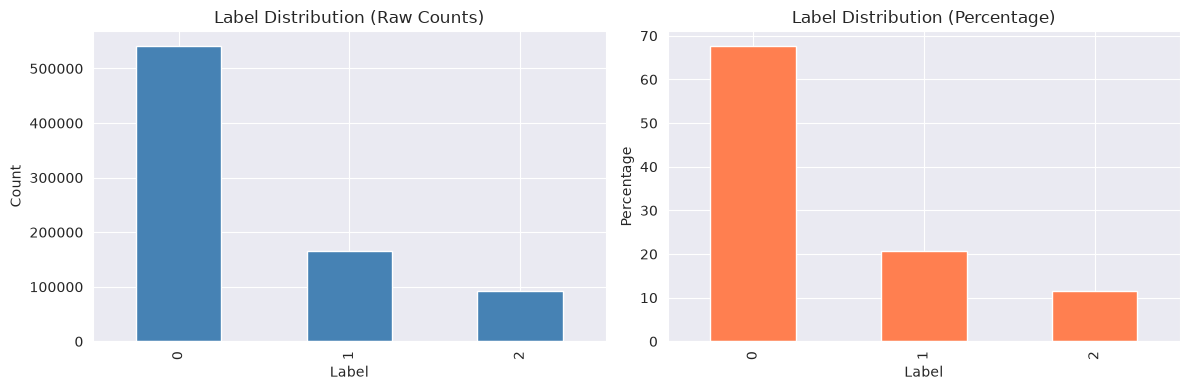

In [6]:
# Visualization: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Label Distribution (Raw Counts)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Label')

(train_df['label'].value_counts(normalize=True).sort_index() * 100).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Label Distribution (Percentage)')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Label')
plt.tight_layout()
plt.show()

## 5. Measurement Distributions

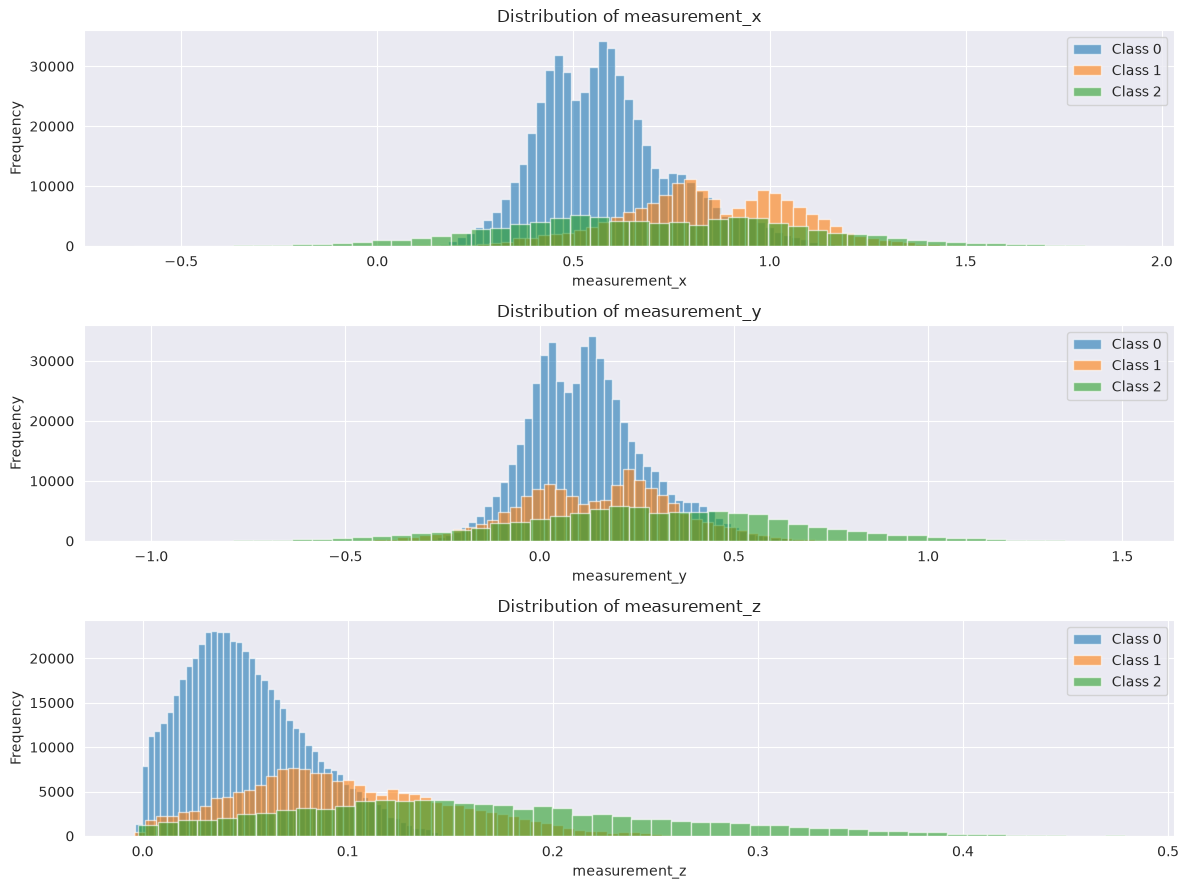

In [7]:
# Visualization: Measurement distributions by label
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
measurements = ['measurement_x', 'measurement_y', 'measurement_z']
for idx, m in enumerate(measurements):
    for label in sorted(train_df['label'].unique()):
        data = train_df[train_df['label'] == label][m]
        axes[idx].hist(data, alpha=0.6, bins=50, label=f'Class {label}')
    axes[idx].set_title(f'Distribution of {m}')
    axes[idx].set_xlabel(m)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
plt.tight_layout()
plt.show()

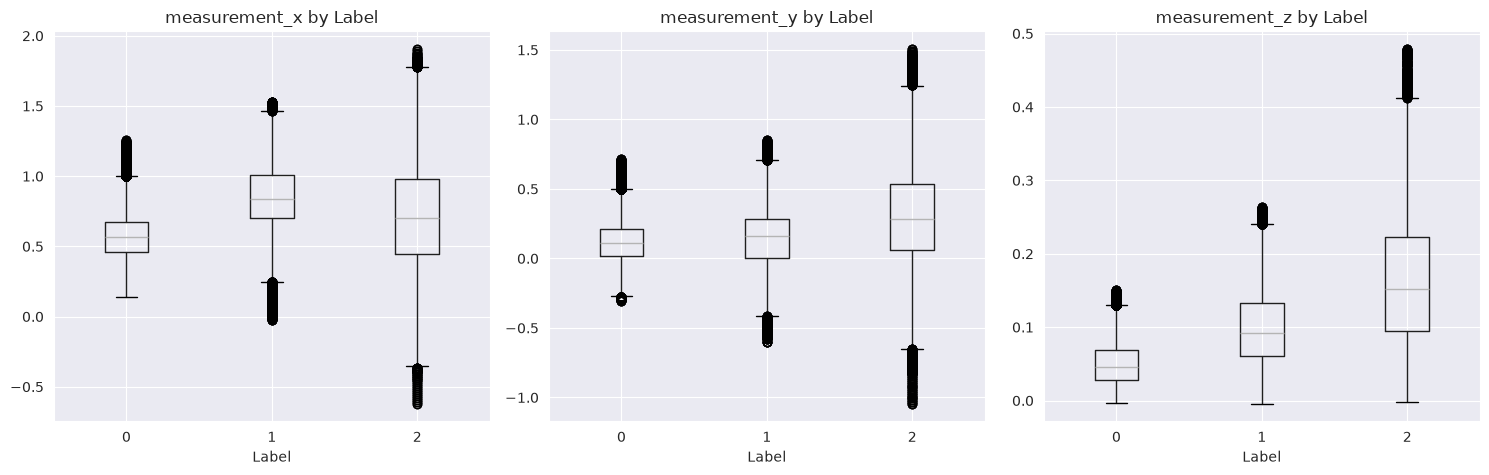

In [8]:
# Boxplots by label
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, m in enumerate(measurements):
    train_df.boxplot(column=m, by='label', ax=axes[idx])
    axes[idx].set_title(f'{m} by Label')
    axes[idx].set_xlabel('Label')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Correlation matrix:
               measurement_x  measurement_y  measurement_z
measurement_x       1.000000       0.140652       0.189140
measurement_y       0.140652       1.000000       0.166459
measurement_z       0.189140       0.166459       1.000000


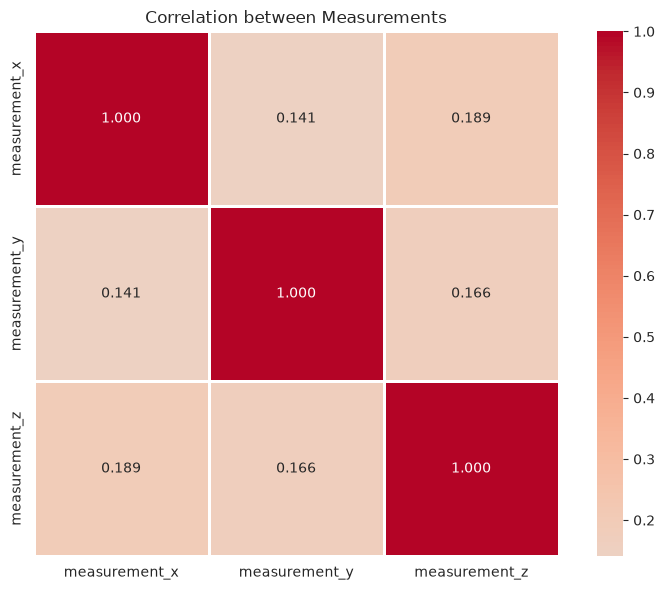

In [9]:
# Correlation between measurements
corr = train_df[['measurement_x', 'measurement_y', 'measurement_z']].corr()
print("Correlation matrix:")
print(corr)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation between Measurements')
plt.tight_layout()
plt.show()

## 7. Time Series Patterns

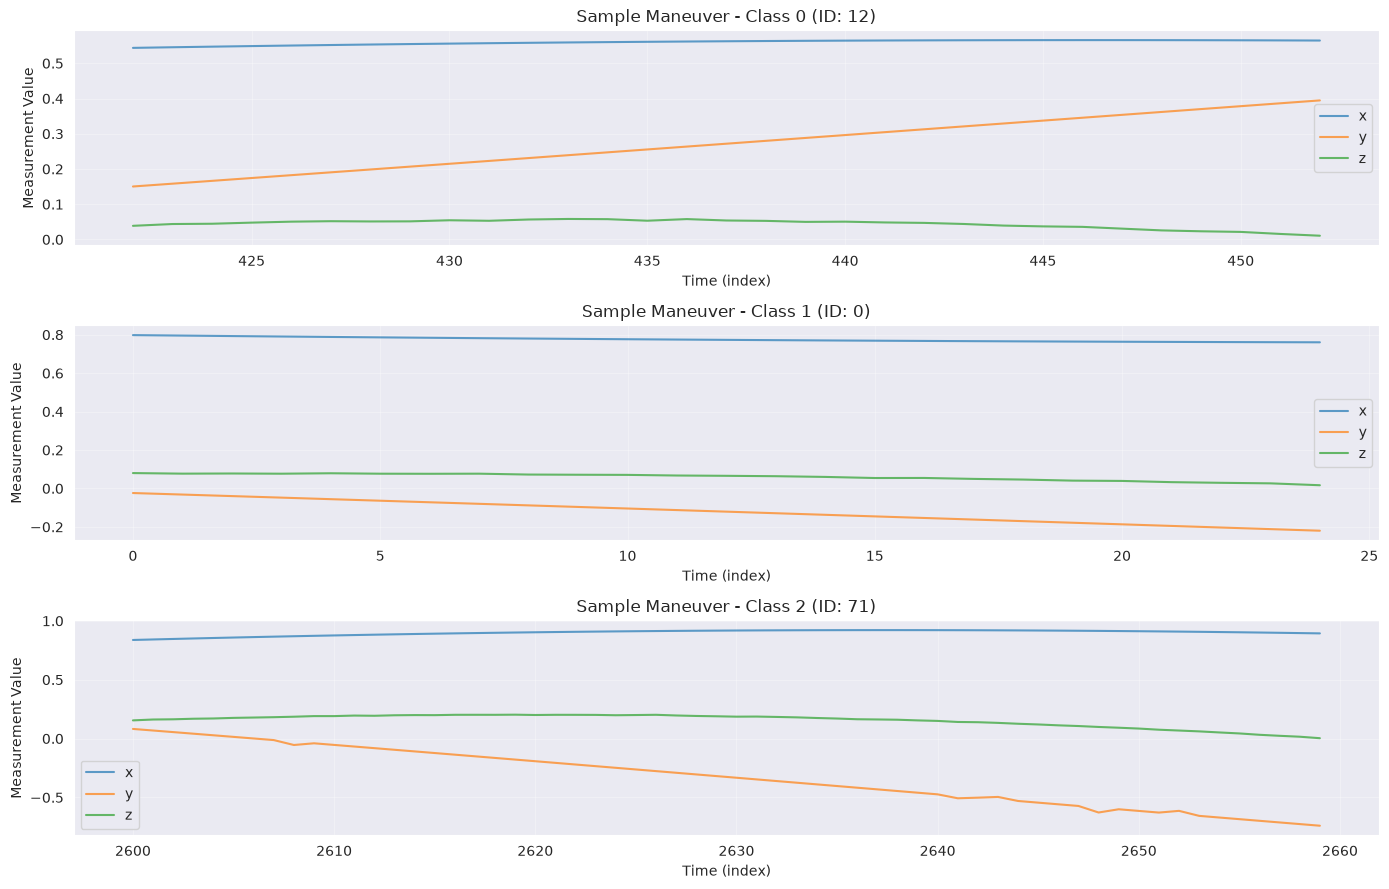

In [10]:
# Sample a few maneuvers to visualize time series patterns
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for label_val, ax in zip(sorted(train_df['label'].unique()), axes):
    sample_maneuver = train_df[train_df['label'] == label_val]['maneuver_Id'].iloc[0]
    sample_data = train_df[train_df['maneuver_Id'] == sample_maneuver]
    
    ax.plot(sample_data.index, sample_data['measurement_x'], label='x', alpha=0.7)
    ax.plot(sample_data.index, sample_data['measurement_y'], label='y', alpha=0.7)
    ax.plot(sample_data.index, sample_data['measurement_z'], label='z', alpha=0.7)
    
    ax.set_title(f'Sample Maneuver - Class {label_val} (ID: {sample_maneuver})')
    ax.set_xlabel('Time (index)')
    ax.set_ylabel('Measurement Value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Test Set Overview

In [11]:
# Test set info
print("Test set sample:")
print(test_df.head())
print(f"\nTest set shape: {test_df.shape}")
print(f"Unique maneuvers: {test_df['maneuver_Id'].nunique()}")
print(f"\nMeasurements per maneuver (test):")
print(test_df.groupby('maneuver_Id').size().describe())

Test set sample:
   Unnamed: 0  maneuver_Id                   timestamp  measurement_x  \
0           0        25705  2015-10-10 23:40:29.106000       0.528361   
1           1        25705  2015-10-10 23:40:29.106000       0.528195   
2           2        25705  2015-10-10 23:40:29.206000       0.527988   
3           3        25705  2015-10-10 23:40:29.256000       0.527739   
4           4        25705  2015-10-10 23:40:29.306000       0.527449   

   measurement_y  measurement_z  
0       0.197757       0.061193  
1       0.202128       0.062136  
2       0.206497       0.059240  
3       0.210864       0.056590  
4       0.215228       0.053298  

Test set shape: (200000, 6)
Unique maneuvers: 6351

Measurements per maneuver (test):
count    6351.000000
mean       31.491104
std        14.741880
min         1.000000
25%        21.000000
50%        30.000000
75%        40.000000
max       105.000000
dtype: float64


## 9. Summary

In [12]:
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nTraining Set:")
print(f"  Total rows: {len(train_df):,}")
print(f"  Unique maneuvers: {train_df['maneuver_Id'].nunique():,}")
print(f"  Class distribution: {train_df['label'].value_counts().sort_index().to_dict()}")
print(f"\nTest Set:")
print(f"  Total rows: {len(test_df):,}")
print(f"  Unique maneuvers: {test_df['maneuver_Id'].nunique():,}")
print(f"\nMeasurements:")
print(f"  Features: measurement_x, measurement_y, measurement_z")
print(f"  Time index: timestamp (MM:SS.S format)")
print(f"\nKey Observations:")
print(f"  - Class imbalance: Class 0 is majority")
print(f"  - Variable maneuver length: {train_df.groupby('maneuver_Id').size().min()} to {train_df.groupby('maneuver_Id').size().max()} measurements")
print(f"  - 3D accelerometer data: x, y, z measurements")
print(f"\nNext Steps:")
print(f"  1. Run flight_maneuver_training.ipynb for model training")
print(f"  2. Run flight_maneuver_submission.ipynb for test predictions")


DATASET SUMMARY

Training Set:
  Total rows: 799,994
  Unique maneuvers: 25,706
  Class distribution: {0: 541030, 1: 165979, 2: 92985}

Test Set:
  Total rows: 200,000
  Unique maneuvers: 6,351

Measurements:
  Features: measurement_x, measurement_y, measurement_z
  Time index: timestamp (MM:SS.S format)

Key Observations:
  - Class imbalance: Class 0 is majority
  - Variable maneuver length: 1 to 101 measurements
  - 3D accelerometer data: x, y, z measurements

Next Steps:
  1. Run flight_maneuver_training.ipynb for model training
  2. Run flight_maneuver_submission.ipynb for test predictions
